<a href="https://colab.research.google.com/github/florence-aikins/detection-of-fake-and-real-mages/blob/main/fake_vs_real_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib scikit-learn
!pip install lightning-utilities
!pip install torchmetrics
!pip install torchinfo
!pip install streamlit torchvision pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 131.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score
import torch.optim as optim
import os
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import v2
from tqdm import tqdm
from PIL import Image
from torchvision.transforms.functional import to_pil_image
from torchinfo import summary
import streamlit as st

In [ ]:
device = 'cuda' if torch.cuda.is_available()\
          else 'mps' if torch.backends.mps.is_available()\
          else 'cpu'
print(device)

cuda


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
os.makedirs('/content/drive/MyDrive/kaggle', exist_ok=True)

In [ ]:
!mkdir -p /root/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!mv kaggle.json /content/drive/MyDrive/kaggle/

mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets list

ref                                                                      title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                           Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          32573        679                1  
laveshjadon/ai-impact-on-students                                        Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000           2555         59                1  
abdulmaliklodhra/social-media-addiction-and-mental-health-dataset        Social Media Addiction & Mental Health Dataset        13975225  2026-05-22 10:15:52.543000 

In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:06<00:00, 17.1MB/s]



In [ ]:
os.listdir()

['.config',
 'cifake-real-and-ai-generated-synthetic-images.zip',
 'drive',
 'sample_data']

In [ ]:
!unzip -n cifake-real-and-ai-generated-synthetic-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/REAL/4500 (10).jpg  
  inflating: train/REAL/4500 (2).jpg  
  inflating: train/REAL/4500 (3).jpg  
  inflating: train/REAL/4500 (4).jpg  
  inflating: train/REAL/4500 (5).jpg  
  inflating: train/REAL/4500 (6).jpg  
  inflating: train/REAL/4500 (7).jpg  
  inflating: train/REAL/4500 (8).jpg  
  inflating: train/REAL/4500 (9).jpg  
  inflating: train/REAL/4500.jpg     
  inflating: train/REAL/4501 (10).jpg  
  inflating: train/REAL/4501 (2).jpg  
  inflating: train/REAL/4501 (3).jpg  
  inflating: train/REAL/4501 (4).jpg  
  inflating: train/REAL/4501 (5).jpg  
  inflating: train/REAL/4501 (6).jpg  
  inflating: train/REAL/4501 (7).jpg  
  inflating: train/REAL/4501 (8).jpg  
  inflating: train/REAL/4501 (9).jpg  
  inflating: train/REAL/4501.jpg     
  inflating: train/REAL/4502 (10).jpg  
  inflating: train/REAL/4502 (2).jpg  
  inflating: train/REAL/4502 (3).jpg  
  inflating: train/REAL/4502 (4).jpg  
  inflating:

In [ ]:
os.listdir('train')

['FAKE', 'REAL']

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
     [0.229, 0.224, 0.225])
])

In [ ]:
train_data = torchvision.datasets.ImageFolder('train', transform=transform)
test_set = torchvision.datasets.ImageFolder('test', transform=transform)

In [ ]:
train_set, val_set = torch.utils.data.random_split(train_data, [0.8, 0.2])

In [ ]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=True)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels[:5])

torch.Size([16, 3, 224, 224])
tensor([1, 0, 1, 0, 1])


In [ ]:
train_data.classes

['FAKE', 'REAL']

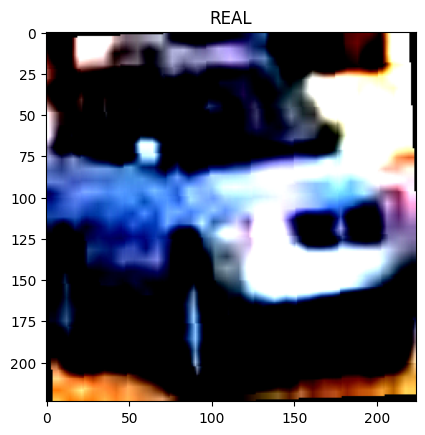

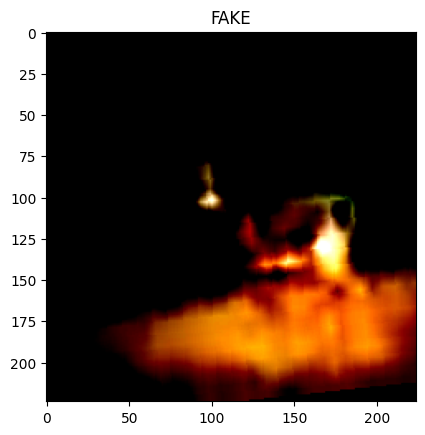

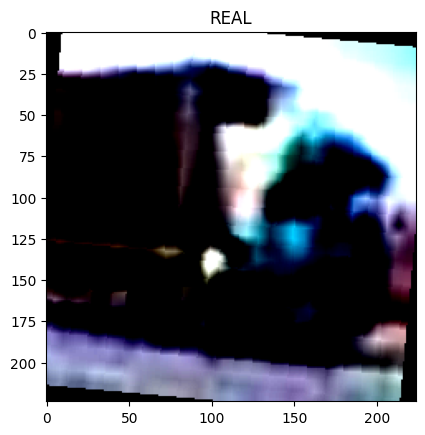

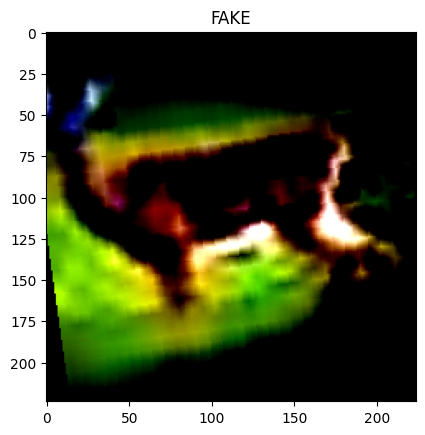

In [ ]:
for i in range(4):
  plt.imshow(images[i].permute(1,2,0))
  plt.title(train_data.classes[labels[i]])
  plt.show()

In [ ]:
nn.LazyConv2d(32, kernel_size = 3, stride = 1, padding = 1)

LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [ ]:
nn.MaxPool2d(kernel_size = 2)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
        nn.LazyConv2d(32, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.LazyConv2d(64, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(128),
        nn.ReLU(),
        nn.Linear(128,2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
model = SimpleCNN().to(device)

In [ ]:
criteria = torch.nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
def train_one_epoch(model, dataloader):
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=2).to(device)
  model.train()

  for X, Y in tqdm(train_loader):
    X=X.to(device)
    Y=Y.to(device)
    optimizer.zero_grad()
    preds = model(X)
    loss = criteria(preds, Y)
    loss.backward()
    optimizer.step()
    preds = preds.argmax(dim=1)
    losses.update(loss, X.size(0))
    acc.update(preds, Y)

  return losses.compute().item(), acc.compute().item()

In [ ]:
def validation_one_epoch(model, dataloader):
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes = 10).to(device)
  model.eval()

  with torch.no_grad():
    for X, Y in tqdm(val_loader):
      X=X.to(device)
      Y=Y.to(device)
      preds = model(X)
      loss = criteria(preds, Y)
      preds = preds.argmax(dim=1)
      losses.update(loss, X.size(0))
      acc.update(preds, Y)

  return losses.compute().item(), acc.compute().item()

In [ ]:
epochs = 10

for i in range(0, epochs):
  train_loss, train_acc = train_one_epoch(model, train_loader)
  val_loss, val_acc = validation_one_epoch(model, val_loader)
  print("epoch:", i, "|train loss:", train_loss, "|train_accuracy", train_acc,
        "|validation loss:", val_loss, "|validation accuracy:", val_acc)

  6%|▋         | 315/5000 [00:22<04:44, 16.49it/s]

In [ ]:
test_confusion_matrix = ConfusionMatrix(task='multiclass', num_classes=2).to(device)
test_acc = Accuracy(task='multiclass', num_classes=2).to(device)

model = model.to(device)
model.eval()
with torch.no_grad():
  for X, Y in test_loader:
    X = X.to(device)
    Y = Y.to(device)
    preds = model(X)
    preds = preds.argmax(dim=1)
    test_confusion_matrix.update(preds, Y)
    test_acc.update(preds, Y)
  print("confusion matrix:\n", test_confusion_matrix.compute())
  print("accuracy:", test_acc.compute().item())

In [ ]:
cm = test_confusion_matrix.compute().cpu().numpy()

In [ ]:
classes = ['Real', 'Fake']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
weights = ResNet18_Weights.DEFAULT
model2 = torchvision.models.resnet18(weights=None)
print(model2)

In [ ]:
num_ftrs = model2.fc.in_features

In [ ]:
model2.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 2)
)
model2 = model2.to(device)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
model2 = model2.to(device)

In [ ]:
v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

In [ ]:
train_transform = v2.Compose([
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
])

In [ ]:
eval_transform=v2.Compose([
    v2.Resize(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
])

In [ ]:
train_data = torchvision.datasets.ImageFolder('train', transform=train_transform)
test_data = torchvision.datasets.ImageFolder('test', transform=eval_transform)
val_data = torchvision.datasets.ImageFolder('train', transform=eval_transform)

In [ ]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_indices, val_indices = torch.utils.data.random_split(range(len(
    train_data)), [train_size, val_size])
train_set = torch.utils.data.Subset(train_data, train_indices)
val_set = torch.utils.data.Subset(train_data, val_indices)

In [ ]:
train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=8, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(val_set, batch_size=8, shuffle=True, num_workers=2)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=8, shuffle=True, num_workers=2)

In [ ]:
criteria = torch.nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

In [ ]:
def train_one_epoch(model2, dataloader):
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=2).to(device)
  model2.train()

  for X, Y in tqdm(train_dataloader):
    X=X.to(device)
    Y=Y.to(device)
    optimizer.zero_grad()
    preds = model2(X)
    loss = criteria(preds, Y)
    loss.backward()
    optimizer.step()
    preds = preds.argmax(dim=1)
    losses.update(loss, X.size(0))
    acc.update(preds, Y)

  return losses.compute().item(), acc.compute().item()

In [ ]:
def validation_one_epoch(model2, dataloader):
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=2).to(device)
  model2.eval()
  with torch.no_grad():
    for X, Y in tqdm(val_dataloader):
      X=X.to(device)
      Y=Y.to(device)
      preds = model2(X)
      loss = criteria(preds, Y)
      preds = preds.argmax(dim=1)
      losses.update(loss, X.size(0))
      acc.update(preds, Y)

  return losses.compute().item(), acc.compute().item()

In [ ]:
history = pd.DataFrame()
epochs = 3
for i in range(0, epochs):
  train_loss, train_acc = train_one_epoch(model2, train_dataloader)
  val_loss, val_acc = validation_one_epoch(model2, val_dataloader)
  statistics = pd.DataFrame({
      'epoch': [i], 'train_loss': [train_loss],
      'train_acc': [train_acc], 'val_loss': [val_loss],
      'val_acc': [val_acc]
  })
  history = pd.concat([history, statistics], ignore_index=True)
  print(statistics.to_dict(orient='records')[0])

In [ ]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(history['epoch'], history['train_loss'], label='train', color='blue')
plt.plot(history['epoch'], history['val_loss'], label='validation', color='red')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history['epoch'], history['train_acc'], label='train', color='blue')
plt.plot(history['epoch'], history['val_acc'], label='validation', color='red')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()

In [ ]:
test_acc = Accuracy(task='multiclass', num_classes=2).to(device)
test_confusion_matrix = ConfusionMatrix(task='multiclass', num_classes=2).to(device)
test_precision = Precision(task='multiclass', num_classes=2).to(device)
test_recall = Recall(task='multiclass', num_classes=2).to(device)
test_f1 = F1Score(task='multiclass', num_classes=2).to(device)

In [ ]:
model2 = model2.to(device)
model2.eval()
with torch.no_grad():
  for X, Y in test_dataloader:
    X = X.to(device)
    Y = Y.to(device)
    preds = model2(X)
    preds = preds.argmax(dim=1)
    test_confusion_matrix.update(preds, Y)
    test_acc.update(preds, Y)
    test_precision.update(preds, Y)
    test_recall.update(preds, Y)
    test_f1.update(preds, Y)

  print("confusion matrix:\n", test_confusion_matrix.compute())
  print("accuracy:", test_acc.compute().item())
  print("precision:", test_precision.compute().item())
  print("recall:", test_recall.compute().item())
  print("f1 score:", test_f1.compute().item())

In [ ]:
cm = test_confusion_matrix.compute().cpu().numpy()

In [ ]:
classes = ['Real', 'Fake']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
def denormalize(tensor):
  mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3,1,1)
  std = torch.tensor([0.229, 0.224, 0.225]).reshape(3,1,1)
  return tensor * std + mean

In [ ]:
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)
images, labels = next(iter(test_dataloader))
model2 = model2.to('cpu')
model2.eval()
with torch.no_grad():
  preds = model2(images)
  preds = preds.argmax(dim=1)

In [ ]:
fig, axes = plt.subplots(4,4, figsize=(8,8))
for idx, ax in enumerate(axes.flat):
  image = images[idx]
  image = denormalize(image)
  image = to_pil_image(image.clamp(0,1))
  ax.imshow(image)
  ax.axis('off')
  ax.set_title("{}".format(classes[preds[idx]]),
               color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()

In [ ]:
def load_model2(model2_path, num_classes=2):
  from torchvision.models import resnet18, ResNet18_Weights
  model2 = resnet18(weights=ResNet18_Weights)
  num_ftrs = model2.fc.in_features
  model2.fc = nn.Sequential(
      nn.Dropout(0.5),
      nn.Linear(num_ftrs, 2)
  )
  model2.load_state_dict(torch.load(model2_path, map_location=device))
  model2=model2.to(device)
  model2.eval()
  return model2

In [ ]:
torch.save(model2.state_dict(), 'model2.pth')

In [ ]:
!ls

In [ ]:
import os
os.listdir('/content')

In [ ]:
!pip install gradio

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
from torchvision.models import resnet18
import torch.nn as nn
import gradio as gr


def load_model2():
  model2 = resnet18(weights = None)
  num_ftrs = model2.fc.in_features
  model2.fc = nn.Sequential(
      nn.Dropout(0.5),
      nn.Linear(num_ftrs, 2)
  )
  return model2

device = torch.device("cpu")
model2.load_state_dict(torch.load('/content/model2.pth', map_location=device))
model2 = model2.to(device)
model2.eval()

model = load_model2()

transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
])

def predict(image):
  image = image.convert("RGB")
  image = transform(image).unsqueeze(0)
  image = image.to(device)

  with torch.no_grad():
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs).item()

  classes = ['Fake', 'Real']
  return classes[pred]

interface = gr.Interface(
    fn = predict,
    inputs = gr.Image(type="pil"),
    outputs = "label",
    title = "real vs fake image classifier"
)

interface.launch(share=True)